In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)

print("Dataset loaded:", df.shape)

Mounted at /content/drive
Dataset loaded: (48536, 28)


Epoch 1/50 - loss: 203342672.00 - recon_loss: 136321568.00 - kl_loss: 67021132.00
Epoch 2/50 - loss: 9888691.00 - recon_loss: 2129400.00 - kl_loss: 7759288.50
Epoch 3/50 - loss: 6154390.00 - recon_loss: 1868707.00 - kl_loss: 4285685.50
Epoch 4/50 - loss: 4397514.00 - recon_loss: 1319216.12 - kl_loss: 3078297.00
Epoch 5/50 - loss: 2829482.50 - recon_loss: 601315.62 - kl_loss: 2228166.75
Epoch 6/50 - loss: 1890330.75 - recon_loss: 243092.70 - kl_loss: 1647238.50
Epoch 7/50 - loss: 1626125.00 - recon_loss: 321357.38 - kl_loss: 1304767.62
Epoch 8/50 - loss: 1285605.00 - recon_loss: 191004.84 - kl_loss: 1094600.50
Epoch 9/50 - loss: 1388464.50 - recon_loss: 418253.72 - kl_loss: 970211.25
Epoch 10/50 - loss: 1090396.12 - recon_loss: 235255.92 - kl_loss: 855140.00
Epoch 11/50 - loss: 1119331.00 - recon_loss: 328317.12 - kl_loss: 791014.00
Epoch 12/50 - loss: 851977.44 - recon_loss: 146153.34 - kl_loss: 705824.38
Epoch 13/50 - loss: 809753.12 - recon_loss: 177850.70 - kl_loss: 631902.12
Epoch 

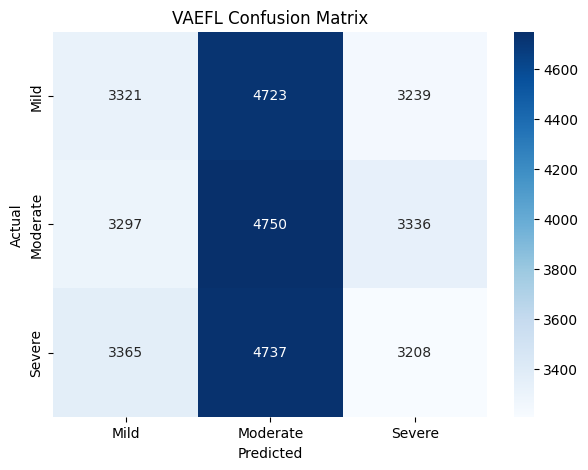

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from keras import layers

# Target
target_col = "Motor_Symptoms"
y = df[target_col].values

X = df.drop(columns=["Patient_ID", target_col], errors="ignore")

# Encode categorical features
for col in X.select_dtypes(include=["object", "category"]).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X = X.values.astype("float32")

# Train/Test/Validation Split: 20% train, 10% val, 70% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.3333, random_state=42, stratify=y_trainval
)


# VAE Params
input_dim = X_train.shape[1]
latent_dim = 16
epochs = 50
batch_size = 32

# Encoder
encoder_inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation="relu")(encoder_inputs)
x = layers.Dense(32, activation="relu")(x)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var])

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(32, activation="relu")(latent_inputs)
x = layers.Dense(64, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="linear")(x)
decoder = keras.Model(latent_inputs, decoder_outputs)

# Training loop
optimizer = tf.keras.optimizers.Adam()

num_batches = int(np.ceil(X_train.shape[0] / batch_size))

for epoch in range(epochs):
    idx = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[idx]

    epoch_loss = 0
    epoch_recon = 0
    epoch_kl = 0

    for i in range(num_batches):
        batch = X_train_shuffled[i*batch_size:(i+1)*batch_size]
        with tf.GradientTape() as tape:
            z_mean, z_log_var = encoder(batch)
            z_log_var = tf.clip_by_value(z_log_var, -10.0, 10.0)
            epsilon = tf.random.normal(shape=tf.shape(z_mean))
            z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

            reconstruction = decoder(z)

            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(batch - reconstruction), axis=1))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, encoder.trainable_weights + decoder.trainable_weights)
        optimizer.apply_gradients(zip(grads, encoder.trainable_weights + decoder.trainable_weights))

        epoch_loss += total_loss.numpy()
        epoch_recon += recon_loss.numpy()
        epoch_kl += kl_loss.numpy()

    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss/num_batches:.2f} - recon_loss: {epoch_recon/num_batches:.2f} - kl_loss: {epoch_kl/num_batches:.2f}")

# VAEFL Feature Extraction
z_train, _ = encoder.predict(X_train)
z_test, _ = encoder.predict(X_test)

# Logistic Regression
clf = LogisticRegression(max_iter=1000)
clf.fit(z_train, y_train)
y_pred = clf.predict(z_test)

# Evaluation
print("\n========================================")
print(f"VAEFL for: {target_col}")
print("========================================")
print("\nVAEFL Results")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted", zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, average="weighted", zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, average="weighted", zero_division=0))

print(classification_report(y_test, y_pred, target_names=["Mild","Moderate","Severe"], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Mild","Moderate","Severe"], yticklabels=["Mild","Moderate","Severe"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VAEFL Confusion Matrix")
plt.show()


Shapes:
X_train: (9707, 26) X_val: (4853, 26) X_test: (33976, 26)
Epoch 1/50 - loss: 230206848.00 - recon_loss: 175121328.00 - kl_loss: 55085464.00
Epoch 2/50 - loss: 8889147.00 - recon_loss: 2013231.38 - kl_loss: 6875920.00
Epoch 3/50 - loss: 6427862.50 - recon_loss: 2157721.75 - kl_loss: 4270143.50
Epoch 4/50 - loss: 4937214.50 - recon_loss: 1690630.38 - kl_loss: 3246585.50
Epoch 5/50 - loss: 3976457.25 - recon_loss: 1327295.75 - kl_loss: 2649164.75
Epoch 6/50 - loss: 2910824.00 - recon_loss: 793096.00 - kl_loss: 2117727.75
Epoch 7/50 - loss: 2154180.50 - recon_loss: 456891.75 - kl_loss: 1697288.88
Epoch 8/50 - loss: 1719328.50 - recon_loss: 333082.28 - kl_loss: 1386246.50
Epoch 9/50 - loss: 1389153.38 - recon_loss: 219654.19 - kl_loss: 1169498.88
Epoch 10/50 - loss: 1304350.38 - recon_loss: 307606.72 - kl_loss: 996743.69
Epoch 11/50 - loss: 1365961.25 - recon_loss: 465128.59 - kl_loss: 900832.62
Epoch 12/50 - loss: 2082320.00 - recon_loss: 1072707.50 - kl_loss: 1009612.00
Epoch 13/5

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



VAEFL for: Disease_Stage

VAEFL Results (Disease Stage)
Accuracy : 0.25135389686837767
Precision: 0.24919087911706522
Recall   : 0.25135389686837767
F1-score : 0.2422989416799904
                 precision    recall  f1-score   support

Pre-Symptomatic       0.26      0.30      0.28      8534
          Early       0.24      0.23      0.24      8423
         Middle       0.26      0.36      0.30      8602
           Late       0.24      0.12      0.16      8417

       accuracy                           0.25     33976
      macro avg       0.25      0.25      0.24     33976
   weighted avg       0.25      0.25      0.24     33976



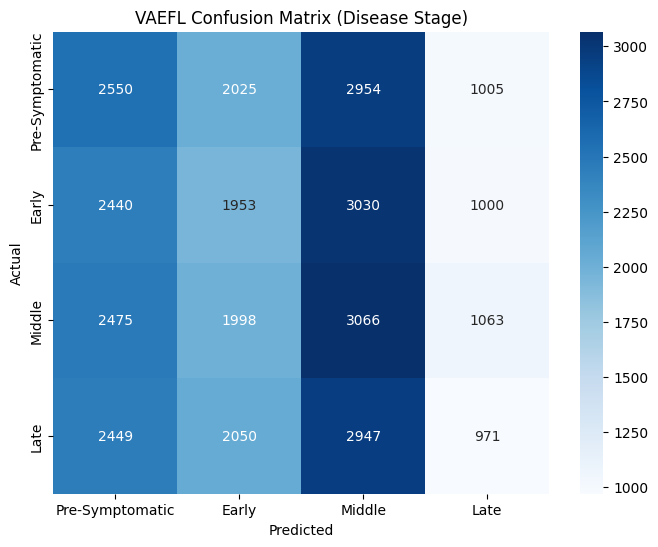

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from keras import layers

# Target & Features
target_col = "Disease_Stage"
y = df[target_col].values
y = LabelEncoder().fit_transform(y)  # encode 4 classes

X = df.drop(columns=["Patient_ID", target_col], errors="ignore")

# Encode categorical features
for col in X.select_dtypes(include=["object", "category"]).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X = X.values.astype("float32")

# Train/Test/Validation Split: 20% train, 10% val, 70% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.3333, random_state=42, stratify=y_trainval
)

print("Shapes:")
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

# VAE Parameters
input_dim = X_train.shape[1]
latent_dim = 16
epochs = 50
batch_size = 32

# Encoder
encoder_inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation="relu")(encoder_inputs)
x = layers.Dense(32, activation="relu")(x)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(32, activation="relu")(latent_inputs)
x = layers.Dense(64, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="linear")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

# Optimizer
optimizer = tf.keras.optimizers.Adam()

# VAE Training Loop
num_batches = int(np.ceil(X_train.shape[0] / batch_size))

for epoch in range(epochs):
    idx = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[idx]

    epoch_loss = 0
    epoch_recon = 0
    epoch_kl = 0

    for i in range(num_batches):
        batch = X_train_shuffled[i*batch_size:(i+1)*batch_size]
        with tf.GradientTape() as tape:
            z_mean_batch, z_log_var_batch = encoder(batch)
            z_log_var_batch = tf.clip_by_value(z_log_var_batch, -10.0, 10.0)
            epsilon = tf.random.normal(shape=tf.shape(z_mean_batch))
            z = z_mean_batch + tf.exp(0.5 * z_log_var_batch) * epsilon

            reconstruction = decoder(z)

            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(batch - reconstruction), axis=1))
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var_batch - tf.square(z_mean_batch) - tf.exp(z_log_var_batch), axis=1)
            )
            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, encoder.trainable_weights + decoder.trainable_weights)
        optimizer.apply_gradients(zip(grads, encoder.trainable_weights + decoder.trainable_weights))

        epoch_loss += total_loss.numpy()
        epoch_recon += recon_loss.numpy()
        epoch_kl += kl_loss.numpy()

    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss/num_batches:.2f} - "
          f"recon_loss: {epoch_recon/num_batches:.2f} - kl_loss: {epoch_kl/num_batches:.2f}")

# VAE Feature Extraction
z_train, _ = encoder.predict(X_train)
z_val, _ = encoder.predict(X_val)
z_test, _ = encoder.predict(X_test)

# Logistic Regression
clf = LogisticRegression(max_iter=1000)
clf.fit(z_train, y_train)
y_pred = clf.predict(z_test)

# Evaluation
print("\n========================================")
print(f"VAEFL for: {target_col}")
print("========================================")
class_names = ["Pre-Symptomatic", "Early", "Middle", "Late"]

print("\nVAEFL Results (Disease Stage)")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted", zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, average="weighted", zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, average="weighted", zero_division=0))

print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VAEFL Confusion Matrix (Disease Stage)")
plt.show()


Shapes:
X_train: (9707, 25) X_val: (4853, 25) X_test: (33976, 25)
Epoch 1/50 - loss: 184255216.00 - recon_loss: 125389312.00 - kl_loss: 58865868.00
Epoch 2/50 - loss: 8931816.00 - recon_loss: 2037149.50 - kl_loss: 6894665.00
Epoch 3/50 - loss: 5912823.00 - recon_loss: 1970847.00 - kl_loss: 3941974.25
Epoch 4/50 - loss: 5402193.50 - recon_loss: 2304803.00 - kl_loss: 3097392.25
Epoch 5/50 - loss: 3766048.00 - recon_loss: 1250645.00 - kl_loss: 2515404.00
Epoch 6/50 - loss: 2670582.25 - recon_loss: 710295.81 - kl_loss: 1960287.38
Epoch 7/50 - loss: 1771864.25 - recon_loss: 275638.62 - kl_loss: 1496225.75
Epoch 8/50 - loss: 1494679.00 - recon_loss: 294442.69 - kl_loss: 1200236.75
Epoch 9/50 - loss: 1325319.62 - recon_loss: 321847.41 - kl_loss: 1003472.75
Epoch 10/50 - loss: 1220566.88 - recon_loss: 352665.50 - kl_loss: 867901.31
Epoch 11/50 - loss: 1104491.25 - recon_loss: 311843.12 - kl_loss: 792648.19
Epoch 12/50 - loss: 965716.81 - recon_loss: 250892.45 - kl_loss: 714824.19
Epoch 13/50 -

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



VAEFL for: Category
Accuracy : 0.5001177301624676
Precision: 0.3032982151829423
Recall   : 0.5001177301624676
F1-score : 0.33379724136260075
                       precision    recall  f1-score   support

        Primary Cause       0.21      0.00      0.00      8560
Trans-acting Modifier       0.50      1.00      0.67     16996
  Cis-acting Modifier       0.00      0.00      0.00      8420

             accuracy                           0.50     33976
            macro avg       0.24      0.33      0.22     33976
         weighted avg       0.30      0.50      0.33     33976



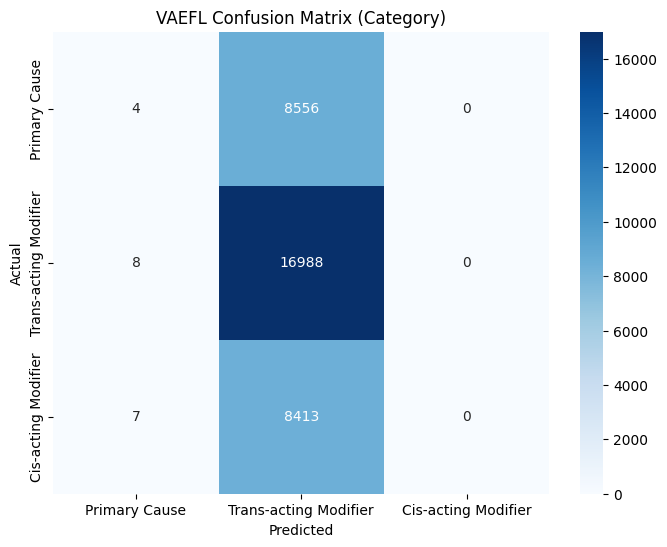

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from keras import layers

# Target & Features
target_col = "Category"

category_cols = ["Category_Primary Cause", "Category_Trans-acting Modifier"]
y = df[category_cols].apply(lambda row:
                            0 if row["Category_Primary Cause"] == 1 else
                            1 if row["Category_Trans-acting Modifier"] == 1 else
                            2, axis=1).values

# Features
X = df.drop(columns=["Patient_ID"] + category_cols, errors="ignore")

# Encode categorical features
for col in X.select_dtypes(include=["object", "category"]).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X = X.values.astype("float32")

# Train/Test/Validation Split: 20% train, 10% val, 70% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.3333, random_state=42, stratify=y_trainval
)

print("Shapes:")
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

# VAE Parameters
input_dim = X_train.shape[1]
latent_dim = 16
epochs = 50
batch_size = 32

# Encoder
encoder_inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation="relu")(encoder_inputs)
x = layers.Dense(32, activation="relu")(x)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(32, activation="relu")(latent_inputs)
x = layers.Dense(64, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="linear")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

# Optimizer
optimizer = tf.keras.optimizers.Adam()

# VAE Training Loop
num_batches = int(np.ceil(X_train.shape[0] / batch_size))

for epoch in range(epochs):
    idx = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[idx]

    epoch_loss = 0
    epoch_recon = 0
    epoch_kl = 0

    for i in range(num_batches):
        batch = X_train_shuffled[i*batch_size:(i+1)*batch_size]
        with tf.GradientTape() as tape:
            z_mean_batch, z_log_var_batch = encoder(batch)
            z_log_var_batch = tf.clip_by_value(z_log_var_batch, -10.0, 10.0)
            epsilon = tf.random.normal(shape=tf.shape(z_mean_batch))
            z = z_mean_batch + tf.exp(0.5 * z_log_var_batch) * epsilon

            reconstruction = decoder(z)

            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(batch - reconstruction), axis=1))
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var_batch - tf.square(z_mean_batch) - tf.exp(z_log_var_batch), axis=1)
            )
            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, encoder.trainable_weights + decoder.trainable_weights)
        optimizer.apply_gradients(zip(grads, encoder.trainable_weights + decoder.trainable_weights))

        epoch_loss += total_loss.numpy()
        epoch_recon += recon_loss.numpy()
        epoch_kl += kl_loss.numpy()

    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss/num_batches:.2f} - "
          f"recon_loss: {epoch_recon/num_batches:.2f} - kl_loss: {epoch_kl/num_batches:.2f}")

# VAE Feature Extraction
z_train, _ = encoder.predict(X_train)
z_val, _ = encoder.predict(X_val)
z_test, _ = encoder.predict(X_test)

# Logistic Regression
clf = LogisticRegression(max_iter=1000)
clf.fit(z_train, y_train)
y_pred = clf.predict(z_test)

# Evaluation
print("\n========================================")
print(f"VAEFL for: {target_col}")
print("========================================")

class_names = ["Primary Cause", "Trans-acting Modifier", "Cis-acting Modifier"]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted", zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, average="weighted", zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, average="weighted", zero_division=0))

print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"VAEFL Confusion Matrix ({target_col})")
plt.show()
